# **Atividade Prática**
<font size=3>

- **Tema:** problemas de buscas complexas.
- **Prazo de entrega:** 22 de Setembro.

---

### **1. Questão:** Busca And-Or
<font size=3>

Imagine que você está programando um robô para **montar um computador**. O robô precisa de um plano que o leve do estado inicial (peças na mesa) ao estado final (computador montado e funcionando). Os **estados** são as etapas da montagem: Peças na mesa, CPU instalada, Placa-mãe no gabinete, etc. Utilizando a **Busca And-Or**, temos que:
- **Nós OR** (*escolhas*): Representam as diferentes opções que o robô tem. Por exemplo, para resolver o sub-problema `Conectar um teclado`, o robô pode `Usar teclado USB` **ou** `Usar teclado Bluetooth`. Qualquer uma das opções resolve o problema.

- **Nós AND** (*incerteza e dependências*): Este é o ponto crucial e a analogia direta ao **Go-To-CD**. Por exemplo, na ação `Ligar para Teste`, o resultado é incerto, podendo ser `Sistema Inicia Normalmente` ou pode ser `Erro de Beep da BIOS`. Um plano robusto precisa saber o que fazer em ambos os casos. O robô precisa ter um sub-plano para o sucesso (continuar a instalação) **e** um sub-plano para o erro (diagnosticar o problema).


<font size=3>
    
- **1.1 Pergunta teórica:** em uma célula **markdown**, explique como esse tipo de algoritmo pode ficar preso em *loops*;

- **1.2 Implementação:** com base na implementação do algoritmo `AndOrSearch` do **_Notebook_ 4**:
  - Defina o problema `ComputerAssemblyProblem`, disponível no pacote `ativ5.py` (**importe o pacote**);
  - O **estado final** deve ser encontrado ao realizar a busca do modelo definido;
  - Plot o resultado com a função `plot_solution_graph` de `ativ5.py`, ela irá receber o estado final da busca.

> **Observação:** faz parte da atividade o(a) estudante investigar as funções e classes contidas em `ativ5.py` e utilizá-las **corretamente**, além de importar qualquer outra biblioteca necessária para cumprir o que se pede na atividade.

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive/')

### AND-OR Search
De acordo com Russel & Norvig (2022) na seção 4.3.2, o algoritmo AND-OR funciona de forma que leva em consideração o não determinismo. Nesse sentido, se o algoritmo for usado em um agente *físico*, fatores problemáticos relacionados aos *atuadores*, por exemplo, podem gerar um problema de *loop*, pois o agente pode confiar que, se a ação for repetida vezes suficientes, ela eventualmente funcionará e o plano terá sucesso. Porém, por se tratar de um problema externo, de modo que o algoritmo não tem como detectar a falha do atuador, ficará repetindo a ação infinitamente não obtendo sucesso.

In [4]:
import numpy as np
import ativ5

In [1]:
class AndOrSearch:

    def __init__(self, problem):
        self.problem = problem

    def search(self):
        """
        Ponto de entrada do algoritmo. Inicia a busca a partir do estado inicial.
        Retorna um plano condicional para o sucesso ou None para falha.
        """
        return self.or_search(self.problem.initial_state, [])

    def or_search(self, state, path):
        """
        Busca por um plano a partir de um estado 'OR'.
        Sucesso se QUALQUER uma de suas ações levar a um plano de sucesso.
        """
    
        if self.problem.goal_test(state):
            return []

        if state in path:
            return None

        for action in self.problem.actions(state):

            results = self.problem.transition_model(state, action)
            plan = self.and_search(results, [state] + path)

            if plan is not None:
                return {'action':action, 'plan':plan}

        return None

    def and_search(self, states, path):
        """
        Busca por um plano a partir de um conjunto de estados 'AND'.
        Sucesso se conseguirmos encontrar um plano para TODOS os estados do conjunto.
        """

        if not isinstance(states, list):
            states = [states]

        sub_plans = {} 

        for s in states:

            plan_for_s = self.or_search(s, path)

            if plan_for_s is None:
                return None

            sub_plans[s] = plan_for_s

        return sub_plans

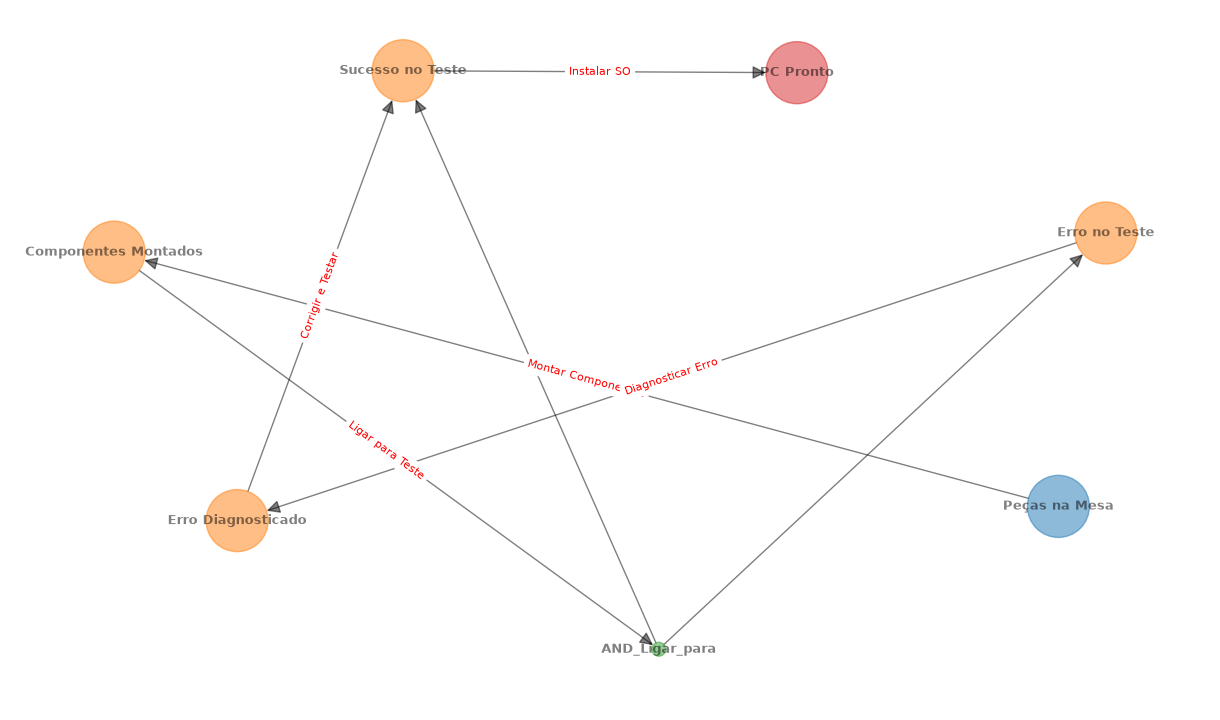

In [6]:
problema1 = ativ5.ComputerAssemblyProblem()

model = AndOrSearch(problema1)

plano_final = model.search()

ativ5.plot_solution_graph(problema1, plano_final)

### **2. Questão:** Busca Online
<font size=3>

Vamos desenvolver o problema de **busca da saída de um labirinto**, onde o agente se move com base no algoritmo de **busca online**.

- **1.1 Pergunta teórica:** em uma célula **markdown**, explique a diferença entre **busca _offline_** de **busca _online_**;

- **1.2 Implementação:** com base na implementação do algoritmo `OnlineDFSAgent` do **_Notebook_ 4**:
  - Defina um labirinto 8 x 8, com base no exemplo:
    <font size=2>
    
    ```python
    
    # 'S' = Início, 'G' = Objetivo, '#' = Parede, '.' = Caminho
    maze = [['S', '.', '.', '.'],
            ['#', '#', '.', '#'],
            ['.', '.', '.', '.'],
            ['.', '#', 'G', '#']]
            
    ```
    <font size=3>

  - Termine a implementação da classe `MazeProblem` abaixo, com base nas dicas de cada método. Observe que o labirinto `maze` é variável da classe `MazeProblem`;
  - Defina o objeto do modelo de busca;
  - Aplique o objeto do modelo na função `simulate_online_search` disponível em `atividade5`. Esta função, de visualização interativa, aprensenta a variável `max_iterations`, a qual você irá estabelecer o número máximo de iterações de busca.
  - Criei um labirinto, que não seja trivial, mas que seu agente possa encontrar a saída em **no máximo 100 iterações**.


### Busca Online (Online Search) x Busca Offline (Offline Search)
De acordo com o material disponibilizado pelo Prof., Dr. Tibério Pereira, nas [seções 4 - 4.1](https://colab.research.google.com/drive/1fRm5OgK-FOVPMFeWD8Nx7Uhms037ArRa#scrollTo=fb03d1cd-f567-47a5-8cc1-d37e8d1fce8c), a *Busca online* permite que sistemas autônomos possam explorar e interagir com ambientes desconhecidos e dinâmicos, de tal forma que o agente *não* conhece previamente os *estados possíveis* para ele ou os efeitos de suas ações.

Por outro lado, ainda com base no material, nas *Buscas Offline*, o agente possui conhecimento prévio acerca do mapa do mundo (ambiente), ou do problema, antes de ir em busca de uma solução, ou seja, a solução é conhecida (se sabe que existe) e só precisa ser alcançada. Todavia, no caso das *Buscas Online* as "coisas" vão sendo conhecidas à medida em que se movem e suas tomadas de decisões, em geral, são feitas com base em informações limitadas.

In [10]:
class MazeProblem(ativ5.Problem):
    """
    Modela o problema de encontrar a saída em um labirinto.
    O labirinto é representado por uma lista de listas (matriz) onde:
    'S' = Ponto de partida (Start)
    'G' = Objetivo (Goal)
    '#' = Parede (obstáculo)
    ' ' = Caminho livre
    """

    def __init__(self, maze_map):
        self.maze_map = maze_map
        self.rows = len(maze_map)
        self.cols = len(maze_map[0])
        initial = self._find_char('S')
        self.goal = self._find_char('G')
        
        super().__init__(
            initial_state = initial, 
            actions = self.get_actions, 
            transition_model = self.apply_action, 
            goal_test = self.goal_test)

    def _find_char(self, char):
        """Função auxiliar para encontrar a coordenada (r, c) de um caractere específico no labirinto."""
        
        for r in range(self.rows):
            for c in range(self.cols):
                if self.maze_map[r][c] == char:
                    return (r, c)  
        return None

    def get_actions(self, state):
        """Retorna as ações válidas ('N', 'S', 'E', 'W') a partir de um dado estado."""

        r, c = state
        possible_actions = []
        
        if r > 0 and self.maze_map[r - 1][c] != '#': 
            possible_actions.append('N')
        
        if r < self.rows - 1 and self.maze_map[r + 1][c] != '#': 
            possible_actions.append('S')

        if c > 0 and self.maze_map[r][c - 1] != '#': 
            possible_actions.append('W')

        if c < self.cols - 1 and self.maze_map[r][c + 1] != '#': 
            possible_actions.append('E')
        
        return possible_actions

    def apply_action(self, state, action):
        """Calcula o estado resultante (novas coordenadas) ao aplicar uma ação."""
        r, c = state

        if action == 'N': return (r - 1, c)
        if action == 'S': return (r + 1, c)
        if action == 'W': return (r, c - 1)
        if action == 'E': return (r, c + 1)

        return state

    def goal_test(self, state):
        """Testa se o estado atual é o estado objetivo."""

        if state == self.goal:
            return True
        else:
            return False
        

In [ ]:
class OnlineDFSAgent:

    def __init__(self, problem):

        self.problem = problem
        self.result = {}            
        self.untried = {}           
        self.unbacktracked = {} 

        # Como o arquivo de base estava incompleto foi utilizada a ferramenta Gemini para completar o trecho que faltava a partir das informações abaixo    
        self.previous_state = None
        self.previous_action = None 

        self.opposite_action = {
            'N': 'S',
            'S': 'N',
            'W': 'E',
            'E': 'W'
        }

    def decide_next_action(self, current_state):
        """
        Decide a próxima ação a ser tomada pelo agente usando busca online em profundidade (DFS).
        """

        if self.problem.goal_test(current_state):
            return "stop"

        if current_state not in self.untried:
            possible_actions = list(self.problem.actions(current_state))

            if self.previous_action is not None and self.previous_action in self.opposite_action:
                # Finaliza trecho feito pelo Gemini. As informações a seguir são parte do que já estava disponibilizado no material de estudo
                
                reverse = self.opposite_action[self.previous_action]
                if reverse in possible_actions:
                    possible_actions.remove(reverse)

            self.untried[current_state] = possible_actions

        if self.previous_state is not None:
            self.result[(self.previous_state, self.previous_action)] = current_state
            self.unbacktracked.setdefault(current_state, []).append(self.previous_state)

        if self.untried.get(current_state):
            action = self.untried[current_state].pop(0)

        else:
            if not self.unbacktracked.get(current_state):
                return "stop" 

            backtrack_to = self.unbacktracked[current_state].pop(0)

            action = None
            for (s, a), res in self.result.items():
                if s == current_state and res == backtrack_to:
                    action = a
                    break

            if action is None:
                for (s, a), res in self.result.items():
                    if res == current_state and s == backtrack_to:
                        action = self.opposite_action[a]
                        break

        self.previous_state = current_state
        self.previous_action = action

        return action


In [14]:
maze = [['S', '.', '.', '.', '#', '.', '.', '#'],
        ['#', '#', '.', '#', '#', '#', '.', '#'],
        ['.', '.', '.', '.', '.', '.', '.', '#'],
        ['.', '#', '#', '#', '#', '#', '.', '#'],
        ['.', '.', '.', '.', '.', '.', '.', '#'],
        ['#', '#', '.', '#', '.', '#', '#', '#'],
        ['.', '.', '.', '.', '.', '.', '.', '#'],
        ['#', '#', '.', '#', 'G', '#', '.', '#']]

problema2 = MazeProblem(maze)

model = OnlineDFSAgent(problema2)

resultado = ativ5.simulate_online_search(model)

Agente em: (7, 4) | Objetivo: (7, 4)
--------------------
 S  .  .  .  #  .  .  # 
 #  #  .  #  #  #  .  # 
 .  .  .  .  .  .  .  # 
 .  #  #  #  #  #  .  # 
 .  .  .  .  .  .  .  # 
 #  #  .  #  .  #  #  # 
 .  .  .  .  .  .  .  # 
 #  #  .  #  A  #  .  # 
--------------------
Agente decide: stop (Passo: 52)

Objetivo alcançado!

Caminho total percorrido pelo agente (incluindo backtrack):
(0, 0) -> (0, 1) -> (0, 2) -> (1, 2) -> (2, 2) -> (2, 1) -> (2, 0) -> (3, 0) -> (4, 0) -> (4, 1) -> (4, 2) -> (5, 2) -> (6, 2) -> (7, 2) -> (6, 2) -> (6, 1) -> (6, 0) -> (6, 1) -> (6, 2) -> (6, 3) -> (6, 4) -> (5, 4) -> (4, 4) -> (4, 3) -> (4, 2) -> (4, 3) -> (4, 4) -> (4, 5) -> (4, 6) -> (3, 6) -> (2, 6) -> (1, 6) -> (0, 6) -> (0, 5) -> (0, 6) -> (1, 6) -> (2, 6) -> (2, 5) -> (2, 4) -> (2, 3) -> (2, 2) -> (2, 3) -> (2, 4) -> (2, 5) -> (2, 6) -> (3, 6) -> (4, 6) -> (4, 5) -> (4, 4) -> (5, 4) -> (6, 4) -> (7, 4)


### Algumas considerações
A sequência de ações, realizadas pelo agente, segue a sequência dada pelo método `get_actions`. Nesse sentido, quando se está no estado (6, 4) ao invés de ir direto para o estado (7, 4), que é o objetivo final - *meta*, são feitos vários outros passos até alcançar essa *meta*. Diante disso, cabe destacar que é possível alterar a sequência de estados para que, a partir do estado (6, 4) possa seguir direto para a *meta* (7, 4). Entretanto a sequência só faria sentido para a configuração especificada, ou seja, ao mudar a configuração do labirinto, pode ocorrer de seus passos não serem mais tão precisos.

Não obstante, isso ocorre devido ao acesso limitado às informações sobre a *meta* e o *ambiente*, corroborando com as características do algoritmo de Busca Online (Online Search), ou seja, como não se sabe onde a *meta* está, é feita uma varredura no campo de espaços possíveis ao qual se tem acesso (vai sendo conhecido à medida em que explora) e, além disso, é realizado o salvando das informações do caminho percorrido (explorado), através do método `decide_next_action`, para então decidir para qual caminho seguir (novo estado) que ainda não foi explorado.

### Referências:

- Russell & Norvig. Artificial intelligence: a modern approach, 2022.
- PEREIRA, Tibério. Buscas em ambientes complexos. Disponível em: [material didático](https://colab.research.google.com/drive/1fRm5OgK-FOVPMFeWD8Nx7Uhms037ArRa#scrollTo=11609b15-d16c-4a94-9b6b-041cc35886f0). Acesso em 23/09/2026
